Ce code montre les étapes principales d’un GAN :

Charger les données

Définir le générateur

Définir le discriminateur

Entraîner les deux réseaux en compétition

Générer de nouvelles images

Epoch [10/10]  Loss_D: 0.0000  Loss_G: 18.2305


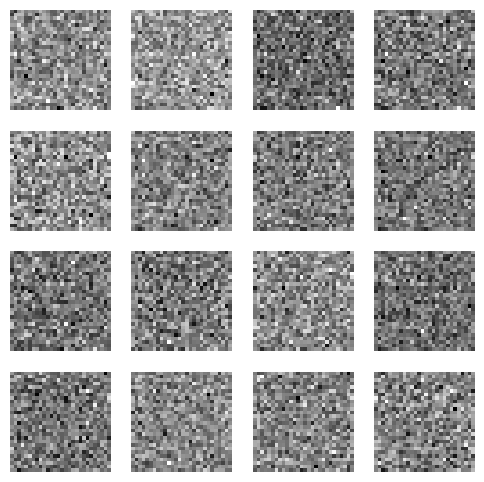

In [1]:
# ============================================
# GAN simple avec PyTorch
# ============================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt


# ============================================
# Paramètres
# ============================================

batch_size = 64
latent_dim = 100
epochs = 10
lr = 0.0002


# ============================================
# Dataset MNIST : La base utilisée est MNIST, qui contient 70 000 images de chiffres manuscrits (0–9).
# ============================================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
 #transforms.Compose : Permet d’appliquer plusieurs transformations successivement.
 
 #transforms.ToTensor()
#### Convertit l’image :
    #### format PIL / numpy
    #### → tensor PyTorch
#### Et transforme les pixels :
#### 0..255→0..1
### transforms.Normalize((0.5,), (0.5,)) : moyenne = 0.5 et  écart-type = 0.5---> Avantage : apprentissage plus stable et convergence plus rapide
 
dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)
# Le DataLoader sert à envoyer les données au réseau neuronal pendant l’entraînement.

# ============================================
# Générateur
# ============================================

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        # Réseau de neurones qui transforme un vecteur aléatoire (latent)
        # en une image générée (784 pixels = 28x28)
        self.model = nn.Sequential(

            # couche fully connected : latent_dim -> 256 neurones
            nn.Linear(latent_dim, 256),
            nn.ReLU(True),  # fonction d'activation

            # couche cachée : 256 -> 512 neurones
            nn.Linear(256, 512),
            nn.ReLU(True),

            # couche de sortie : 512 -> 784 pixels (image MNIST aplatie)
            nn.Linear(512, 784),
            nn.Tanh()  # sortie normalisée entre [-1,1]
        )

    def forward(self, x):
        # passe l'entrée x (bruit aléatoire) dans le réseau
        # et retourne une image générée
        return self.model(x)


# ============================================
# Discriminateur
# ============================================

class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        # Réseau de neurones qui prend une image (784 pixels aplatis)
        # et retourne une probabilité qu'elle soit réelle (vraie image MNIST)
        self.model = nn.Sequential(

            # couche fully connected : 784 -> 512 neurones
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),  # fonction d'activation avec petite pente négative

            # couche cachée : 512 -> 256 neurones
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            # couche de sortie : 256 -> 1 neurone
            nn.Linear(256, 1),
            nn.Sigmoid()  # sortie entre 0 et 1 (probabilité que l'image soit réelle)
        )

    def forward(self, x):
        # passe l'image x dans le réseau et retourne la probabilité qu'elle soit réelle
        return self.model(x)


# ============================================
# Initialisation
# ============================================

# Crée une instance du générateur
generator = Generator()

# Crée une instance du discriminateur
discriminator = Discriminator()

# Définition de la fonction de perte binaire
# BCELoss = Binary Cross Entropy Loss
# utilisée pour comparer la sortie du discriminateur avec les vraies/faux labels
criterion = nn.BCELoss()

# Optimiseur pour le générateur (mise à jour des poids)
# Adam = algorithme de descente de gradient adaptatif
optimizer_G = optim.Adam(generator.parameters(), lr=lr)

# Optimiseur pour le discriminateur
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr) 


## ============================================
# Entraînement d’un GAN 
# ============================================

for epoch in range(epochs):  # boucle sur le nombre d'epochs

    for real_images, _ in dataloader:  # boucle sur les batchs d'images MNIST

        batch_size_current = real_images.size(0)  # taille du batch
        real_images = real_images.view(batch_size_current, 784)  # aplatissement 28x28 -> 784

        # Création des labels pour le Discriminateur
        real_labels = torch.ones(batch_size_current, 1)  # label 1 pour images réelles
        fake_labels = torch.zeros(batch_size_current, 1)  # label 0 pour images générées

        # -------------------------
        # Entraînement du Discriminateur
        # -------------------------

        # Calcul de la perte sur les vraies images
        outputs = discriminator(real_images)  # prédiction du discriminateur
        loss_real = criterion(outputs, real_labels)  # BCE loss avec label réel

        # Génération d’images artificielles par le générateur
        noise = torch.randn(batch_size_current, latent_dim)  # bruit aléatoire
        fake_images = generator(noise)  # images générées

        # Calcul de la perte sur les images générées
        outputs = discriminator(fake_images.detach())  # detach: ne met pas à jour le générateur
        loss_fake = criterion(outputs, fake_labels)  # BCE loss avec label fake

        # Perte totale du Discriminateur
        loss_D = loss_real + loss_fake

        # Backpropagation et optimisation
        optimizer_D.zero_grad()  # reset gradients
        loss_D.backward()        # calcul des gradients
        optimizer_D.step()       # mise à jour des poids du discriminateur
       # -------------------------
# Entraînement du Générateur
# -------------------------

# Génération de bruit aléatoire pour le batch courant
noise = torch.randn(batch_size_current, latent_dim)

# Génération d’images artificielles à partir du bruit
fake_images = generator(noise)

# Le Discriminateur évalue les images générées
outputs = discriminator(fake_images)

# Calcul de la perte du Générateur
# Ici, on utilise des labels "1" pour tromper le Discriminateur
loss_G = criterion(outputs, real_labels)

# Backpropagation et optimisation du Générateur
optimizer_G.zero_grad()  # reset gradients
loss_G.backward()        # calcul des gradients
optimizer_G.step()       # mise à jour des poids du Générateur

# Affichage des pertes pour chaque epoch
print(f"Epoch [{epoch+1}/{epochs}]  Loss_D: {loss_D.item():.4f}  Loss_G: {loss_G.item():.4f}")

# ============================================
# Génération d'images avec le Générateur
# ============================================

# Création de 16 vecteurs de bruit aléatoire
noise = torch.randn(16, latent_dim)

# Génération d'images à partir du bruit et conversion en numpy
generated_images = generator(noise).detach().numpy()  # detach pour ne pas suivre le gradient

# Création d’une grille 4x4 pour afficher les images
fig, axes = plt.subplots(4, 4, figsize=(6,6))

# Boucle pour afficher chaque image générée
for i, ax in enumerate(axes.flat):
    ax.imshow(generated_images[i].reshape(28,28), cmap='gray')  # reshape 784 -> 28x28
    ax.axis('off')  # pas d’axes

# Affichage de la figure
plt.show()